In [1]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS


In [2]:
df_beyondblue = pd.read_csv("beyondblue_visualized.csv")
df_beyondblue.head()

,keyword,post_content_preview,thread_url,post_date,comments,num_comments,post_content_preview_clean,comments_clean,post_length,num_comments_length,post_text_lemmas,comments_lemma,post_month,post_year
0,anxiety,Hi my name is Michelle and I have hadAnxietymy...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎23-05-2025,"[""Dear Michelle ~Welcome here to the Support F...",2,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety coped ...,200,160,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety cope f...,5,2025
1,anxiety,"Hi, I’ve suffered on and off fromanxietyover...",https://forums.beyondblue.org.au/t5/welcome-an...,‎28-05-2025,['Hello new member and welcome to the forum.Pl...,4,suffered fromanxietyover life recent years rea...,new member welcome forumplease arrived place n...,173,106,suffer fromanxietyover life recent year diffic...,new member welcome forumplease arrive place no...,5,2025
2,anxiety,"I have had chronicanxietysince 2016, but I hav...",https://forums.beyondblue.org.au/t5/anxiety/an...,‎06-01-2025,"['Dear Guest-65543263,I can very much relate t...",9,chronicanxietysince managed bay medicationexer...,dear guest relate written perimenopause sympto...,186,966,chronicanxietysince manage bay medicationexerc...,dear guest relate write perimenopause symptom ...,1,2025
3,anxiety,Hello I struggle with very badanxietyand panic...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-03-2025,"['Hello any advice please would help', ""Hi don...",4,struggle badanxietyand panic attacks finally g...,advice ashamed struggle tell struggling helps ...,197,109,struggle badanxietyand panic attack finally go...,advice ashamed struggle tell struggle help lov...,3,2025
4,anxiety,I’ve recently sold my mortgage free home that ...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-06-2025,"[""Hi KCT welcomeAnxiety is a serious condition...",3,recently sold mortgage free home lived years c...,kct welcomeanxiety condition underestimated po...,192,189,recently sell mortgage free home live year cit...,kct welcomeanxiety condition underestimate pot...,6,2025


/var/folders/x7/xrth4_p955x331lrb98xvffh0000gn/T/ipykernel_7991/3984760969.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_severity = df_beyondblue.groupby('year_month').apply(


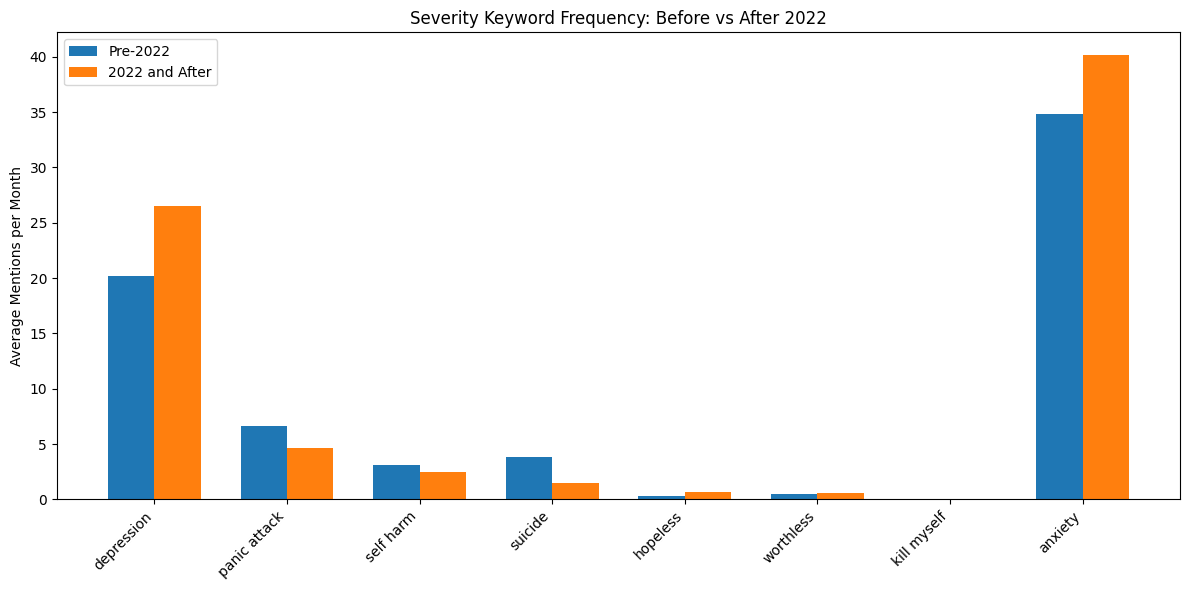

In [3]:

#Step 1: Define severity keywords (lemmatized form)
severity_keywords = ['depression', 'panic attack', 'self harm', 'suicide', 'hopeless', 'worthless', 'kill myself','anxiety']

# Step 2: Create datetime from year and month
df_beyondblue['year_month'] = pd.to_datetime(df_beyondblue['post_year'].astype(str) + '-' + df_beyondblue['post_month'].astype(str) + '-01')

# Step 3: Count keywords using post_text_lemmas
monthly_severity = df_beyondblue.groupby('year_month').apply(
    lambda group: pd.Series({
        keyword: group['post_text_lemmas'].str.contains(keyword, case=False).sum()
        for keyword in severity_keywords
    })
)

# Step 4: Split by pre-2022 and post-2022
pre_2022 = monthly_severity[monthly_severity.index < '2022-01-01']
post_2022 = monthly_severity[monthly_severity.index >= '2022-01-01']

# Step 5: Calculate average mentions
avg_pre = pre_2022.mean()
avg_post = post_2022.mean()

# Step 6: Plotting
labels = avg_pre.index
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, avg_pre.values, width, label='Pre-2022')
ax.bar(x + width/2, avg_post.values, width, label='2022 and After')

ax.set_ylabel("Average Mentions per Month")
ax.set_title("Severity Keyword Frequency: Before vs After 2022")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import re


severity_keywords = {
    "high": [
        "suicide", "kill myself", "want to die", "self harm", "end my life",
        "overdose", "cutting", "hang myself", "can't go on", "ending it all",
        "kill me", "take my life"
    ],
    "moderate": [
        "panic attack", "can't cope", "severe anxiety", "desperate", 
        "hopeless", "worthless", "crying all day", "mental breakdown",
        "no one cares", "giving up"
    ],
    "low": [
        "feeling down", "sad", "stressed", "lonely", "not okay", "tired of life",
        "empty", "anxious", "scared", "lost", "hard time"
    ]
}

# Assign scores
severity_scores = {
    "high": 3,
    "moderate": 2,
    "low": 1
}


def preprocess_text(text):
    """Lowercase, remove special characters for clean matching."""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()


def classify_severity(text):
    text = preprocess_text(text)
    score = 0

    # Count occurrences of keywords in each severity level
    for level, words in severity_keywords.items():
        for word in words:
            if word in text:
                score += severity_scores[level]
    
    # Final classification thresholds
    if score >= 3:
        return "High"
    elif 2 <= score < 3:
        return "Moderate"
    elif 1 <= score < 2:
        return "Low"
    else:
        return "Normal"


df_beyondblue['severity_level'] = df_beyondblue['post_content_preview_clean'].apply(classify_severity)


severity_counts = df_beyondblue['severity_level'].value_counts()
print("Severity Level Distribution:\n", severity_counts)



Severity Level Distribution:
 severity_level
Normal      14680
Low          1430
Moderate     1182
High          974
Name: count, dtype: int64


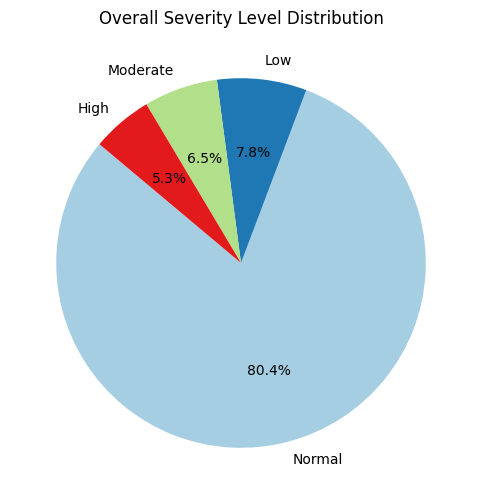

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
    startangle=140, colors=['#a6cee3','#1f78b4','#b2df8a','#e31a1c'])
plt.title('Overall Severity Level Distribution')
plt.show()



In [6]:
#convert the current dataaframe to a csv file
df_beyondblue.to_csv("beyondblue_swk.csv", index=False)